### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [85]:
import tensorflow
from tensorflow.keras import Model, layers, callbacks, optimizers

### Step 2: Constant

In [95]:
FILE_PATH = './data/abalone.data'
COLUMN_NAMES = ['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight', 'VisceraWeight', 'ShellWeight', 'Rings']
RANDOM_SEED = 42
EPOCHS = 50
BATCH_SIZE = 64

### Step 3: Load Data

In [7]:
df = pd.read_csv(FILE_PATH, names=COLUMN_NAMES)

In [8]:
df.head()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


#### Split Data

In [11]:
train, value = train_test_split(
    df,
    test_size=0.4,
    random_state=RANDOM_SEED
)

In [12]:
value, test = train_test_split(
    value,
    test_size=0.5,
    random_state=RANDOM_SEED
)

In [13]:
len(train), len(value), len(test)

(2506, 835, 836)

### Step 4: Exploaring Data

#### Basic Info

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Length,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
Diameter,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
Height,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
WholeWeight,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
ShuckedWeight,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
VisceraWeight,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
ShellWeight,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050
Rings,4177.0,9.933684,3.224169,1.0000,8.0000,9.0000,11.000,29.0000


In [18]:
pd.DataFrame(
    {
        'null': round(100*df.isnull().sum()/len(df), 2),
        'nunique': df.nunique(),
        'type': df.dtypes
    }
)

,null,nunique,type
Sex,0.0,3,object
Length,0.0,134,float64
Diameter,0.0,111,float64
Height,0.0,51,float64
WholeWeight,0.0,2429,float64
ShuckedWeight,0.0,1515,float64
VisceraWeight,0.0,880,float64
ShellWeight,0.0,926,float64
Rings,0.0,28,int64


#### Feature Distribution

In [25]:
temp = df['Sex'].value_counts()

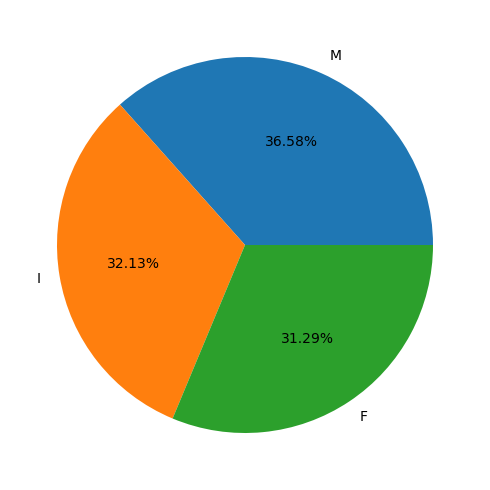

In [27]:
plt.figure(figsize=(5, 5))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index
)
plt.tight_layout()

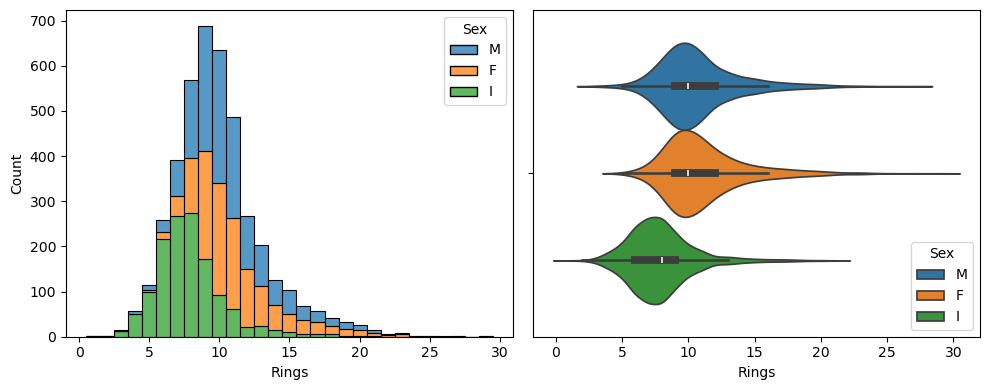

In [46]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(
    x='Rings',
    data=df,
    hue='Sex',
    discrete=True,
    multiple='stack'
)
plt.subplot(1, 2, 2)
sns.violinplot(
    x='Rings',
    data=df,
    hue='Sex'
)
plt.tight_layout()

In [24]:
number_cols = df.select_dtypes(np.number).columns[:-1]

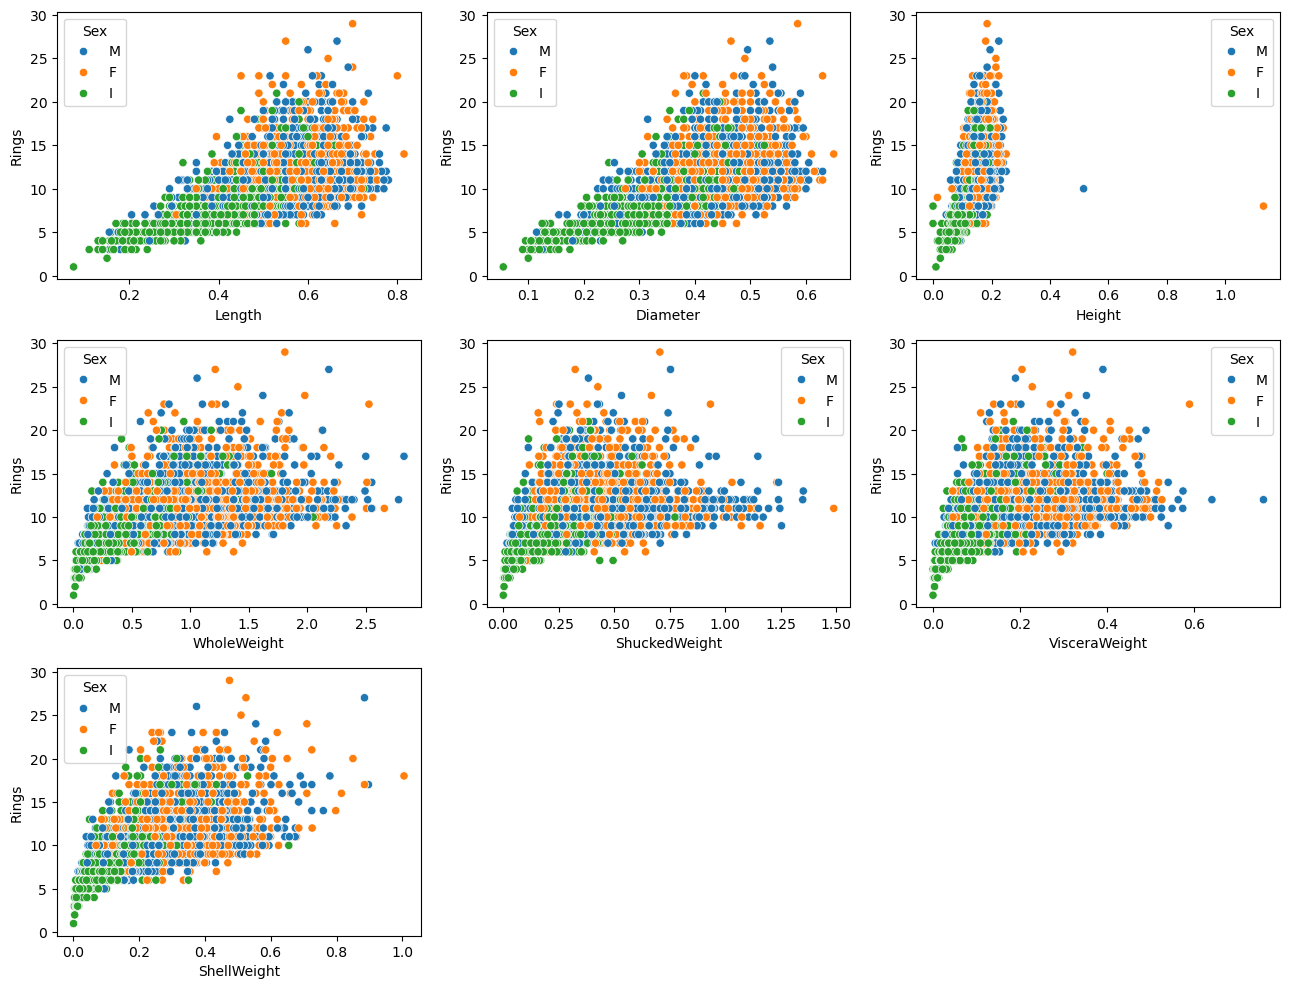

In [40]:
plt.figure(figsize=(13, 10))
for i, col in enumerate(number_cols):
    plt.subplot(3, 3, i+1)
    sns.scatterplot(
        x=col,
        y='Rings',
        data=df,
        hue='Sex'
    )
plt.tight_layout()

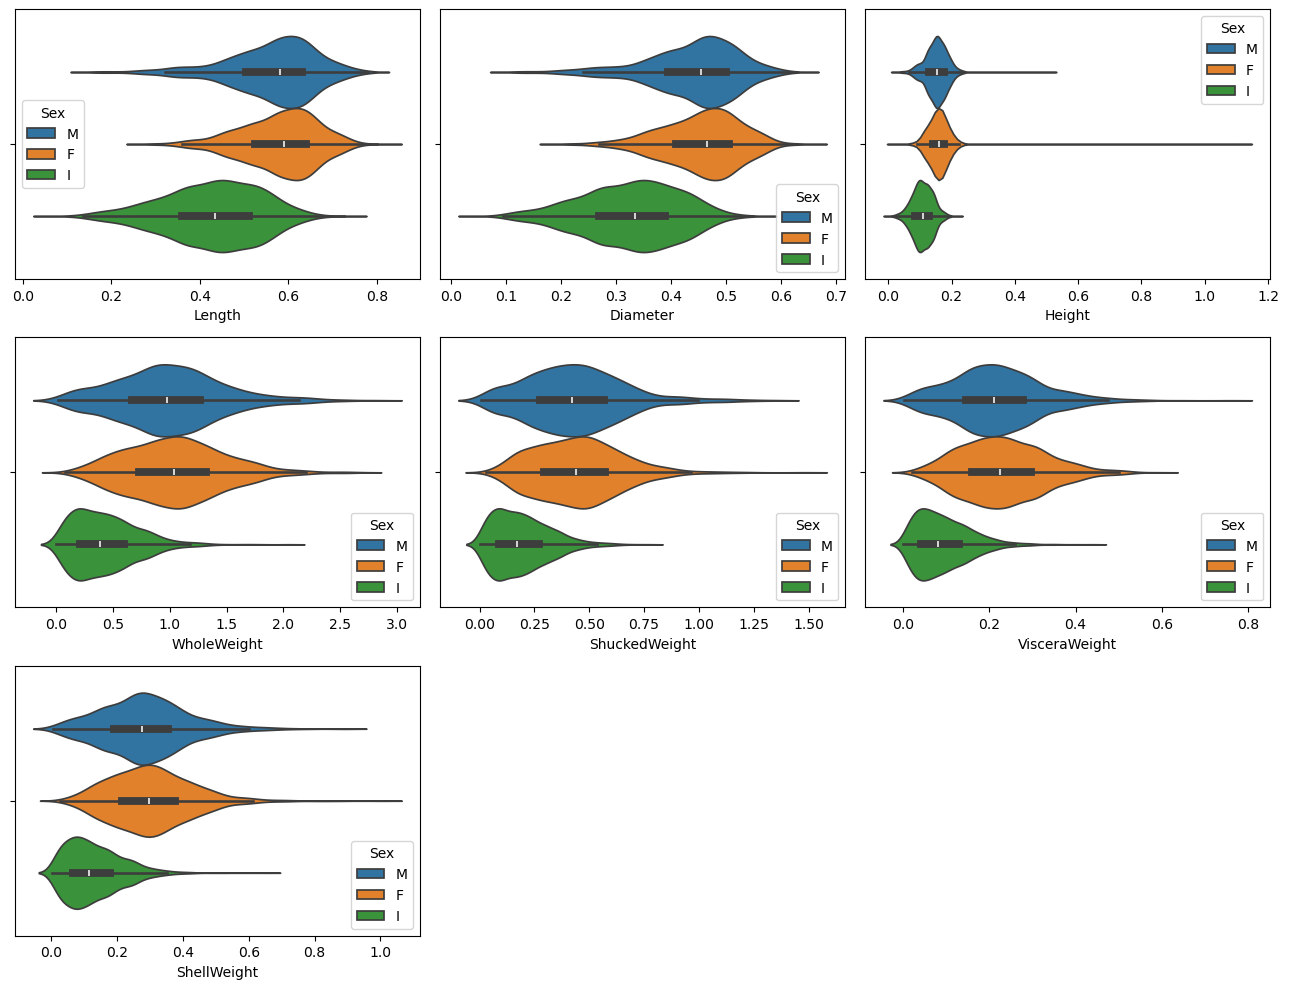

In [42]:
plt.figure(figsize=(13, 10))
for i, col in enumerate(number_cols):
    plt.subplot(3, 3, i+1)
    sns.violinplot(
        x=col,
        data=df,
        hue='Sex'
    )
plt.tight_layout()

### Step 5: Preparing Data

In [48]:
X_train = train.drop(['Rings'], axis=1)
y_train = train['Rings']

In [49]:
X_value = value.drop(['Rings'], axis=1)
y_value = value['Rings']

In [50]:
X_test = test.drop(['Rings'], axis=1)
y_test = test['Rings']

#### Handling Object Columns

In [65]:
cat_cols = X_train.select_dtypes(include='object').columns

In [66]:
cat_cols

Index(['Sex'], dtype='object')

In [70]:
cat_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

#### Handling Number Columns

In [72]:
num_cols = X_train.select_dtypes(exclude='object').columns

In [73]:
num_cols

Index(['Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight',
       'VisceraWeight', 'ShellWeight'],
      dtype='object')

In [74]:
num_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

#### Column Transformer

In [79]:
preprocessor = ColumnTransformer(
    [
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

In [81]:
X_train = preprocessor.fit_transform(X_train)

In [84]:
X_value = preprocessor.transform(X_value)
X_test = preprocessor.transform(X_test)

In [86]:
X_train.shape

(2506, 10)

### Step 6: Model Development

#### Build Model

In [97]:
inputs = layers.Input(shape=(X_train.shape[1],))
x = layers.Dense(256, activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1)(x)

In [98]:
model = Model(inputs, output)

In [90]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │           2,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 70,913 (277.00 KB)

 Trainable params: 69,889 (273.00 KB)

 Non-trainable params: 1,024 (4.00 KB)

#### Compile Model

In [99]:
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

In [100]:
model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae', 'mape']
)

#### Train Model

In [101]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=0,
    restore_best_weights=True
)

In [102]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    verbose=0
)

In [103]:
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_value, y_value),
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 99.3159 - mae: 9.5834 - mape: 101.5894 - val_loss: 88.5980 - val_mae: 8.9587 - val_mape: 92.6065 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 80.9141 - mae: 8.6237 - mape: 91.5202 - val_loss: 71.1617 - val_mae: 7.9453 - val_mape: 81.2952 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 57.3048 - mae: 7.0835 - mape: 74.7401 - val_loss: 47.2870 - val_mae: 6.2923 - val_mape: 62.6898 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 31.9055 - mae: 4.9364 - mape: 50.9511 - val_loss: 23.6749 - val_mae: 4.0881 - val_mape: 38.3734 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.3849 - mae: 2.8551 - mape: 29.1987 - val_loss: 10.2055 - val_mae: 2.2870 - val_mape: 22.5308 - learning_rate: 0.0010
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.8581 - mae: 2.3506 - mape: 25.1832 - val_loss: 7.

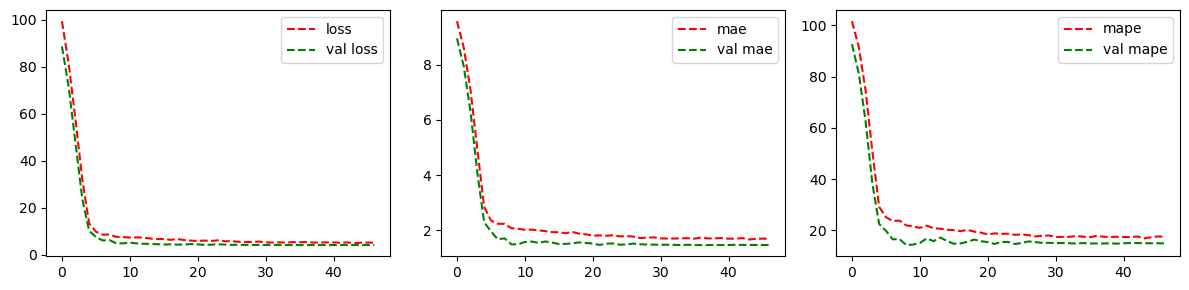

In [107]:
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], 'r--', label='loss')
plt.plot(history.history['val_loss'], 'g--', label='val loss')
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], 'r--', label='mae')
plt.plot(history.history['val_mae'], 'g--', label='val mae')
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(history.history['mape'], 'r--', label='mape')
plt.plot(history.history['val_mape'], 'g--', label='val mape')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [110]:
loss, mae, mape = model.evaluate(X_test, y_test, verbose=0)
print(f'test loss: {round(loss, 3)}, test mae: {round(mae, 3)}, test mape: {round(mape, 3)}')

test loss: 4.321, test mae: 1.465, test mape: 14.541
